# Implementación dunha arquitectura MLP modular
## Manuel Ramallo, Lucía Pérez, Alexandre Lorenzo

In [105]:
import torch
from torch import nn

class MLP(nn.Module):

    def __init__(self, input_neurons, output_neurons, hidden_layers):
        
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        
        # Lista para almacenar capas
        self.layers = nn.ModuleList()
        
        # Engadimos a primeira capa (Entrada -> Primeira capa oculta)
        # Se a lista de ocultas está vacía, conectamos entrada con saída directamente
        if len(hidden_layers) > 0:
            self.layers.append(nn.Linear(input_neurons, hidden_layers[0]))
            
            # Engadimos as capas ocultas intermedias
            # Percorremos dende a primeira oculta ata a penúltima
            for i in range(len(hidden_layers) - 1):
                self.layers.append(nn.Linear(hidden_layers[i], hidden_layers[i+1]))
            
            # Engadimos a última capa (Última oculta -> Saída)
            self.layers.append(nn.Linear(hidden_layers[-1], output_neurons))
        else:
            # Caso especial: Se non hai capas ocultas
            self.layers.append(nn.Linear(input_neurons, output_neurons))

        # Definimos as funcións de activación
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)


    def forward(self, x):
        
        x = self.flatten(x)
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.relu(x)
        
        return x

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import numpy as np
import random

torch.manual_seed(1)
random.seed(1)
np.random.seed(1)


def plot_data_dist(training_labels, test_labels, labels_map):
    c_train = Counter(training_labels)
    class_freq_train = dict(c_train)

    c_test = Counter(test_labels)
    class_freq_test = dict(c_test)

    plt.figure(figsize=(10, 3))
    width = 0.4 
    train_keys = list(class_freq_train.keys())
    test_keys = [key + width for key in class_freq_test.keys()]

    plt.bar(train_keys, class_freq_train.values(), width=width, color='b', align='center', label='Adestramento')
    plt.bar(test_keys, class_freq_test.values(), width=width, color='r', align='center', label='Test')

    plt.xticks([key + width / 2 for key in class_freq_train.keys()], labels_map.values(), rotation='vertical')
    plt.ylabel('Frecuencia')
    plt.xlabel('Categoría')
    plt.legend()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, labels_map):
    conf_matrix = confusion_matrix(y_true, y_pred)
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 10))
    plt.imshow(conf_matrix_normalized, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion matrix')
    plt.colorbar()
    tick_marks = np.arange(10)
    plt.xticks(tick_marks, labels_map.values(), rotation=45)
    plt.yticks(tick_marks, labels_map.values())

    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, f"{conf_matrix[i, j]}", 
                    horizontalalignment="center",
                    color="white" if conf_matrix[i, j] > thresh else "black")

    plt.ylabel('Clase real')
    plt.xlabel('Clase predicida')
    plt.show()

def get_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [107]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [108]:
training_data, _ = torch.utils.data.random_split(training_data, [30000, 30000])

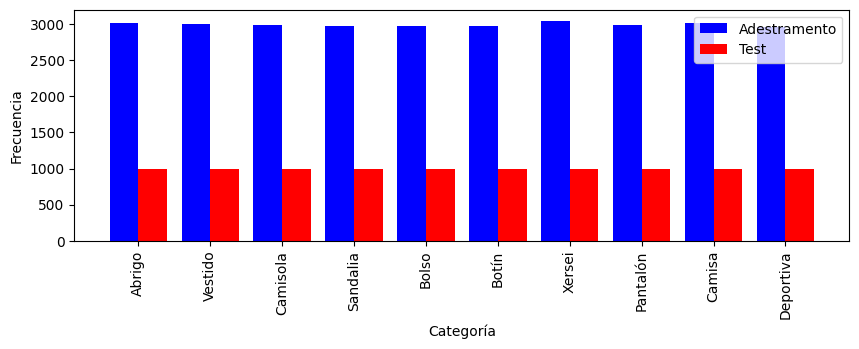

In [109]:
labels_map = {
    0: "Camisola",
    1: "Pantalón",
    2: "Xersei",
    3: "Vestido",
    4: "Abrigo",
    5: "Sandalia",
    6: "Camisa",
    7: "Deportiva",
    8: "Bolso",
    9: "Botín",
}

labels_training = [label for _, label in training_data]
labels_test = [label for _, label in test_data]
plot_data_dist(labels_training, labels_test, labels_map)

In [110]:
batch_size = 8
train_dataloader = DataLoader(dataset=training_data,
                              batch_size=batch_size,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=batch_size,
                             shuffle=True)

In [111]:
mlp = MLP(input_neurons=28*28, output_neurons=10, hidden_layers=[512, 256, 128])

loss_fn = nn.CrossEntropyLoss()

learning_rate = 1e-3
optimizer = torch.optim.SGD(mlp.parameters(), lr=learning_rate)

epochs = 20

In [112]:
def train(dataloader, model, loss_fn, optimizer):
    # Obtemos o número total de lotes
    num_images = len(dataloader.dataset)
    # Poñemos o modelo en modo de adestramento
    model.train()
    # Iteramos sobre os lotes
    n_batch = 0
    for batch_imgs, batch_labels in dataloader:
        # Obtemos as predicións para o lote actual
        batch_predicted_probabilities = model(batch_imgs)
        # Calculamos a perda
        loss = loss_fn(batch_predicted_probabilities, batch_labels)
        # Poñemos a cero os gradientes dos parámetros do modelo
        optimizer.zero_grad()
        # Realizamos a retropropagación para calcular os gradientes de cada parámetro
        loss.backward()
        # Actualizamos os parámetros do modelo utilizando os gradientes calculados
        optimizer.step()

        # Cada 100 lotes, imprimimos a perda e o progreso
        if n_batch % 100 == 0:
            loss, imgs_processed = loss.item(), n_batch * len(batch_imgs)
            print(f"perda: {loss:>7f}  [{imgs_processed:>5d}/{num_images:>5d}]")

        n_batch += 1

    return loss

def test(dataloader, model):
    # Obtemos o número total de imaxes
    num_images = len(dataloader.dataset)
    # Poñemos o modelo en modo de avaliación (sen calcular gradientes)
    model.eval()
    # Inicializamos as variables para gardar a perda e a precisión
    test_loss, correct = 0, 0
    # Inicializamos as listas para gardar as clases predicidas e as clases reais
    test_predicted_classes, test_true_classes = [], []
    with torch.no_grad():
        for batch_imgs, batch_labels in dataloader:
            # Obtemos as predicións para o lote actual
            batch_predicted_probabilities = model(batch_imgs)
            # Calculamos a perda e acumulamos o valor
            test_loss += loss_fn(batch_predicted_probabilities, batch_labels).item()
            # Calculamos as clases predicidas (aquelas con maior probabilidade)
            batch_predicted_classes = batch_predicted_probabilities.argmax(dim=1)
            # Obtemos o número de predicións correctas e acumulamos o valor
            correct += (batch_predicted_classes == batch_labels).sum().item()
            # Gardamos as clases predicidas e as clases reais. Precisamos convertelas a listas de Python coa función tolist()
            test_predicted_classes.extend(batch_predicted_classes.tolist())
            test_true_classes.extend(batch_labels.tolist())
    # Calculamos a perda media e o porcentaxe de predicións correctas (accuracy), dividindo entre o número total de imaxes 
    test_loss /= num_images
    correct /= num_images
    print(f"Perda media: {test_loss:>8f} Accuracy: {correct*100:>0.1f}%\n")

    return test_predicted_classes, test_true_classes

In [113]:
"""train_losses_mlp = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss = train(train_dataloader, mlp, loss_fn, optimizer)
    train_losses_mlp.append(train_loss.item())

test_predicted_classes_mlp, test_true_classes_mlp = test(test_dataloader, mlp)"""

'train_losses_mlp = []\nfor t in range(epochs):\n    print(f"Epoch {t+1}\n-------------------------------")\n    train_loss = train(train_dataloader, mlp, loss_fn, optimizer)\n    train_losses_mlp.append(train_loss.item())\n\ntest_predicted_classes_mlp, test_true_classes_mlp = test(test_dataloader, mlp)'

In [114]:
def test_loss(dataloader, model, loss_fn):
    # Obtemos o número total de imaxes
    num_images = len(dataloader.dataset)
    # Poñemos o modelo en modo de avaliación (sen calcular gradientes)
    model.eval()
    # Inicializamos as variables para gardar a perda e a precisión
    test_loss, correct = 0, 0
    # Inicializamos as listas para gardar as clases predicidas e as clases reais
    test_predicted_classes, test_true_classes = [], []
    with torch.no_grad():
        for batch_imgs, batch_labels in dataloader:
            # Obtemos as predicións para o lote actual
            batch_predicted_probabilities = model(batch_imgs)
            # Calculamos a perda e acumulamos o valor
            test_loss += loss_fn(batch_predicted_probabilities, batch_labels).item()
            # Calculamos as clases predicidas (aquelas con maior probabilidade)
            batch_predicted_classes = batch_predicted_probabilities.argmax(dim=1)
            # Obtemos o número de predicións correctas e acumulamos o valor
            correct += (batch_predicted_classes == batch_labels).sum().item()
            # Gardamos as clases predicidas e as clases reais. Precisamos convertelas a listas de Python coa función tolist()
            test_predicted_classes.extend(batch_predicted_classes.tolist())
            test_true_classes.extend(batch_labels.tolist())
    # Calculamos a perda media e o porcentaxe de predicións correctas (accuracy), dividindo entre o número total de imaxes 
    test_loss /= num_images
    correct /= num_images
    print(f"Perda media: {test_loss:>8f} Accuracy: {correct*100:>0.1f}%\n")

    return test_loss

In [115]:
# Realiza nesta celda o exercicio anterior (non modifiques as celdas anteriores)
from sklearn.model_selection import train_test_split
import copy 
from torch.utils.data import DataLoader, random_split

train_losses_mlp = []
val_losses_mlp = []
epochs = 20
best_val_loss = float('inf')
best_model = None
patience = 3
current_patience = 0
#Dividir modelo en adestramento e validación 85-15
train_size = int(0.85 * len(training_data))  # 85% para entrenamiento
val_size = len(training_data) - train_size  # 15% para validación

train_dataset, val_dataset = random_split(training_data, [train_size, val_size])

# crear DataLoaders a partir dos datasets
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False)

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss = train(train_dataloader, mlp, loss_fn, optimizer)
    train_losses_mlp.append(train_loss.item())

    # Evaluar conxunto de val
    val_loss = test_loss(val_dataloader, mlp, loss_fn)
    val_losses_mlp.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = copy.deepcopy(mlp.state_dict())
        current_patience = 0
    else:
        current_patience += 1
        if current_patience >= patience:
            print("Early stopping")
            break
mlp.load_state_dict(best_model)

test_predicted_classes_mlp, test_true_classes_mlp = test(test_dataloader, mlp)

Epoch 1
-------------------------------
perda: 2.306976  [    0/25500]
perda: 2.317778  [  800/25500]
perda: 2.312624  [ 1600/25500]
perda: 2.298792  [ 2400/25500]
perda: 2.301977  [ 3200/25500]
perda: 2.272063  [ 4000/25500]
perda: 2.298744  [ 4800/25500]
perda: 2.293800  [ 5600/25500]
perda: 2.300531  [ 6400/25500]
perda: 2.287324  [ 7200/25500]
perda: 2.279911  [ 8000/25500]
perda: 2.269402  [ 8800/25500]
perda: 2.273455  [ 9600/25500]
perda: 2.277041  [10400/25500]
perda: 2.262546  [11200/25500]
perda: 2.275974  [12000/25500]
perda: 2.226077  [12800/25500]
perda: 2.252580  [13600/25500]
perda: 2.274221  [14400/25500]
perda: 2.273362  [15200/25500]
perda: 2.247929  [16000/25500]
perda: 2.229479  [16800/25500]
perda: 2.236885  [17600/25500]
perda: 2.237901  [18400/25500]
perda: 2.212707  [19200/25500]
perda: 2.241407  [20000/25500]
perda: 2.181206  [20800/25500]
perda: 2.220782  [21600/25500]
perda: 2.232918  [22400/25500]
perda: 2.140324  [23200/25500]
perda: 2.099761  [24000/25500]

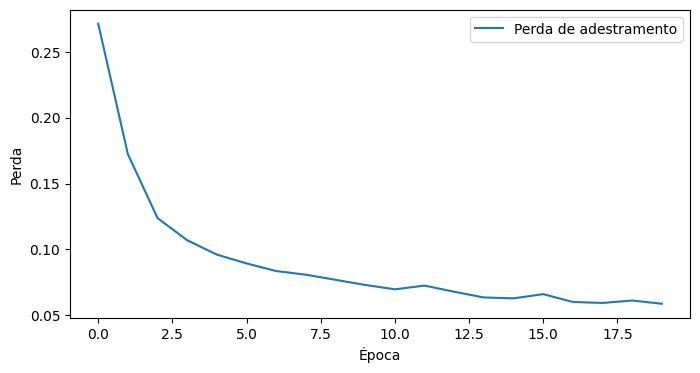

In [116]:
plt.figure(figsize=(8, 4))
plt.plot(val_losses_mlp, label='Perda de adestramento')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.show()

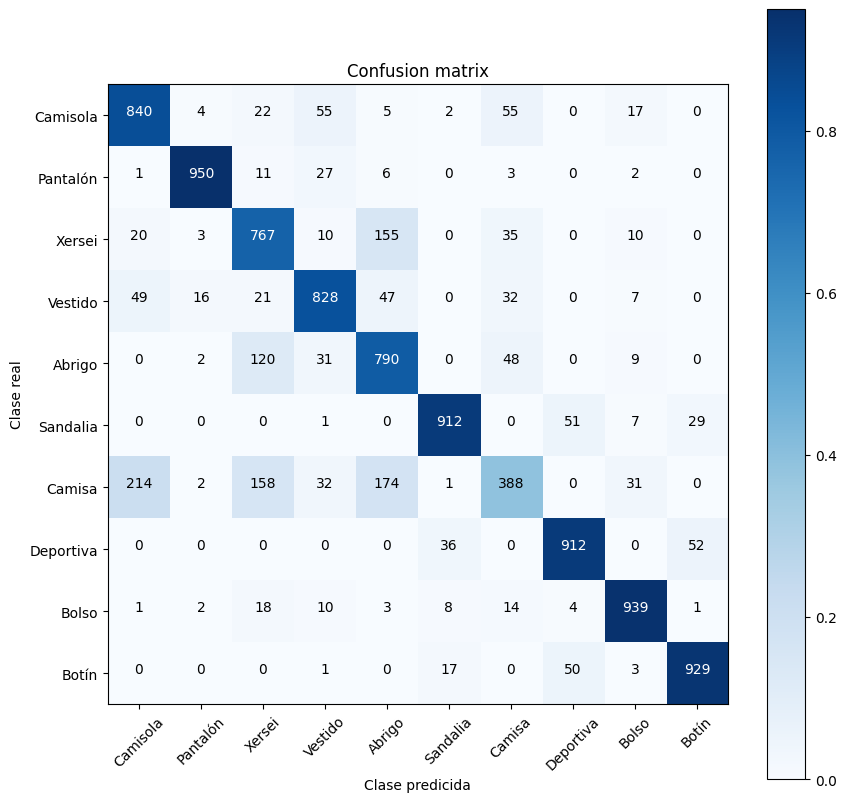

In [117]:
plot_confusion_matrix(y_true=test_true_classes_mlp, y_pred=test_predicted_classes_mlp, labels_map=labels_map)